In [1]:
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 50.2 MB/s eta 0:00:00


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from qutip import (about, basis, destroy, mesolve, ptrace, qeye,
                   tensor, wigner, anim_wigner)
# set a parameter to see animations in line
from matplotlib import rc
rc('animation', html='jshtml')

%matplotlib inline

In [3]:
w_c=1.0*2*np.pi
w_a=1.0*2*np.pi
gamma=0.005*2*np.pi
kappa=0.05*2*np.pi
N=15
g=0.05*2*np.pi
n_th_a=0.0
use_rwa=True
tlist=np.linspace(0,25,101)


In [4]:
psi0=tensor(basis(N,0),basis(2,1))
a=tensor(destroy(N),qeye(2))
sm=tensor(qeye(N),destroy(2))
if use_rwa==True:
  H=w_c*a.dag()*a + w_a*sm.dag()*sm+ g*(a.dag()*sm + a*sm.dag())
else:
  H=w_c*a.dag()*a + w_a*sm.dag()*sm + g*(a + a.dag())*(sm+ sm.dag())

In [5]:
c_ops=[]
rate=kappa*(1+n_th_a)
if rate>0.0:
  c_ops.append(np.sqrt(rate)*a)

rate=kappa*n_th_a
if rate>0.0:
  c_ops.append(np.sqrt(rate)*a.dag())

rate=gamma
if rate>0.0:
  c_ops.append(np.sqrt(rate)*sm)

In [6]:
output=mesolve(H,psi0,tlist,c_ops,e_ops=[a.dag()*a,sm.dag()*sm])

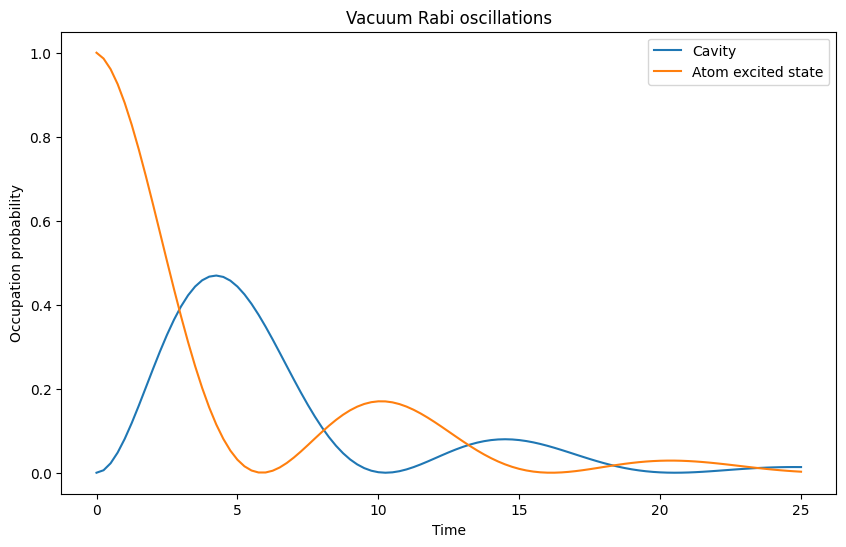

In [7]:
n_c = output.expect[0]
n_a = output.expect[1]

fig, axes = plt.subplots(1, 1, figsize=(10, 6))

axes.plot(tlist, n_c, label="Cavity")
axes.plot(tlist, n_a, label="Atom excited state")
axes.legend(loc=0)
axes.set_xlabel("Time")
axes.set_ylabel("Occupation probability")
axes.set_title("Vacuum Rabi oscillations");

In [8]:
outputs=mesolve(H,psi0,tlist,c_ops)

In [9]:
output.states

[]

In [10]:
t_idx=np.where([tlist==t for t in [0.0,5.0,15.0,25.0]])[1]

In [11]:
tlist[t_idx]

array([ 0.,  5., 15., 25.])

In [14]:
rho_list=[outputs.states[i] for i in t_idx]

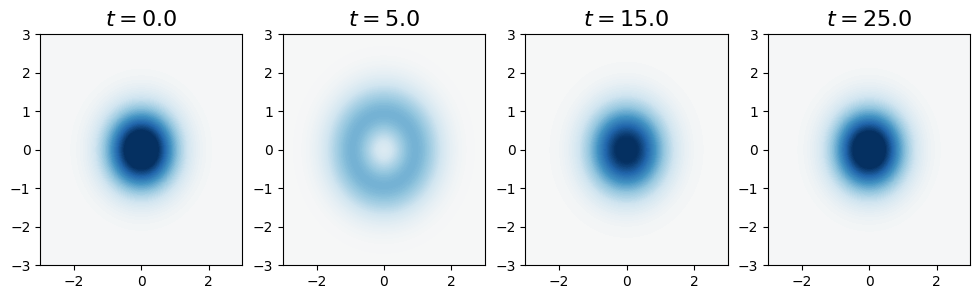

In [16]:
xvec=np.linspace(-3,3,200)
fig, axes = plt.subplots(1, len(rho_list), sharex=True,
                         figsize=(3 * len(rho_list), 3))
for idx,rho in enumerate(rho_list):
  rho_cavity=ptrace(rho,0)
  W=wigner(rho_cavity,xvec,xvec)
  axes[idx].contourf(
        xvec,
        xvec,
        W,
        100,
        norm=mpl.colors.Normalize(-0.25, 0.25),
        cmap=plt.get_cmap("RdBu"),
    )

  axes[idx].set_title(r"$t = %.1f$" % tlist[t_idx][idx], fontsize=16)

## Simple Machine Learning Model Example: Linear Regression

This section demonstrates a simple linear regression model using `scikit-learn`. We will generate some synthetic data, train a model to find the linear relationship, and then visualize the results.

In [ ]:
# Import necessary libraries
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 1. Generate some synthetic data
np.random.seed(0)
X = np.random.rand(100, 1) * 10  # 100 data points between 0 and 10
y = 2 * X + 1 + np.random.randn(100, 1) * 2  # y = 2x + 1 with some noise

# Visualize the generated data
plt.figure(figsize=(8, 6))
plt.scatter(X, y, label='Generated Data')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Generated Synthetic Data')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 2. Create and train a Linear Regression model
model = LinearRegression()
model.fit(X, y)

print(f"Model Intercept: {model.intercept_[0]:.2f}")
print(f"Model Coefficient (slope): {model.coef_[0][0]:.2f}")

In [ ]:
# 3. Make predictions using the trained model
X_new = np.array([[0], [10]])  # New data points for prediction
y_pred = model.predict(X_new)

# 4. Visualize the original data, the true relationship, and the model's predictions
plt.figure(figsize=(8, 6))
plt.scatter(X, y, label='Original Data')
plt.plot(X_new, 2 * X_new + 1, color='green', linestyle='--', label='True Relationship (2x + 1)')
plt.plot(X_new, y_pred, color='red', linewidth=2, label='Model Predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Model Fit')
plt.legend()
plt.grid(True)
plt.show()